In [27]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
data=pd.read_csv("../data/DataSet.csv")


In [28]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB
None


In [29]:
print(data.head())

   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
3                     5                     1.0                 37  
4                    16                     5.0                 68  


In [30]:
print(data.describe())

          Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
count  1000.000000  1000.000000           1000.000000              970.000000   
mean    500.500000    10.059970             16.982000                4.579381   
std     288.819436     5.696656              7.204553                2.914394   
min       1.000000     0.590000              5.000000                0.000000   
25%     250.750000     5.105000             11.000000                2.000000   
50%     500.500000    10.190000             17.000000                5.000000   
75%     750.250000    15.017500             23.000000                7.000000   
max    1000.000000    19.990000             29.000000                9.000000   

       Delivery_Time_min  
count        1000.000000  
mean           56.732000  
std            22.070915  
min             8.000000  
25%            41.000000  
50%            55.500000  
75%            71.000000  
max           153.000000  


In [31]:
numer_col=['Distance_km','Preparation_Time_min','Courier_Experience_yrs','Delivery_Time_min']
categ_col=['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']
print('numeric columns :',numer_col)
print('Categorical columns :',categ_col)

numeric columns : ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']
Categorical columns : ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']


In [32]:
print(data.isnull().sum())

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


In [33]:
for col in numer_col:
    data[col].fillna(data[col].median())
for col in categ_col:
    data[col].fillna(data[col].mode()[0])
print(data.isnull().sum())

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


In [34]:
print(data.shape) ## how many rows are left

(1000, 9)


In [35]:
##data.to_csv("../data/cleaned_data.csv",index=False)

data=pd.read_csv("../data/cleaned_data.csv")

In [36]:
###confirm column names
numer_col=['Distance_km','Preparation_Time_min','Courier_Experience_yrs','Delivery_Time_min']
categ_col=['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']
print('Rows ,cols:',data.shape)
data.head()

Rows ,cols: (1000, 9)


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [37]:
##correlation matrix(numbers)
corr=data[numer_col].corr()
print(corr['Delivery_Time_min'].sort_values(ascending=False))

Delivery_Time_min         1.000000
Distance_km               0.780998
Preparation_Time_min      0.307350
Courier_Experience_yrs   -0.090433
Name: Delivery_Time_min, dtype: float64


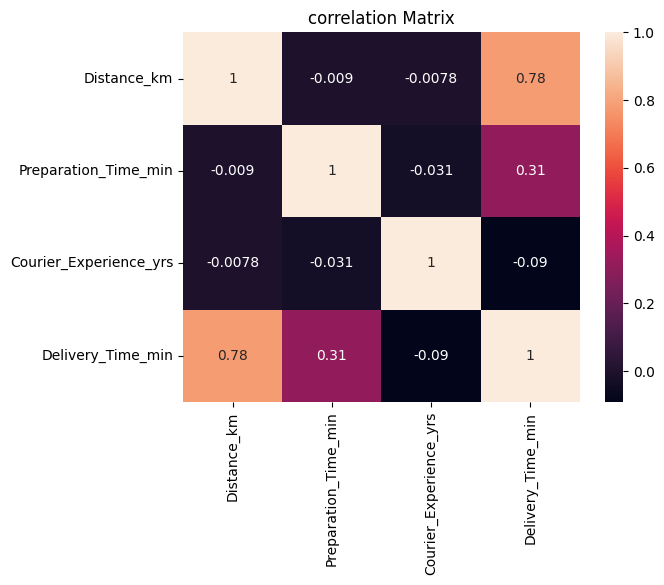

In [38]:
##heatmap visuel de correlation
sns.heatmap(corr,annot=True)
plt.title("correlation Matrix")
plt.show()

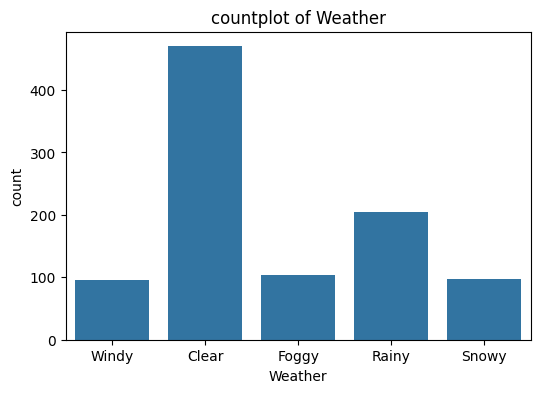

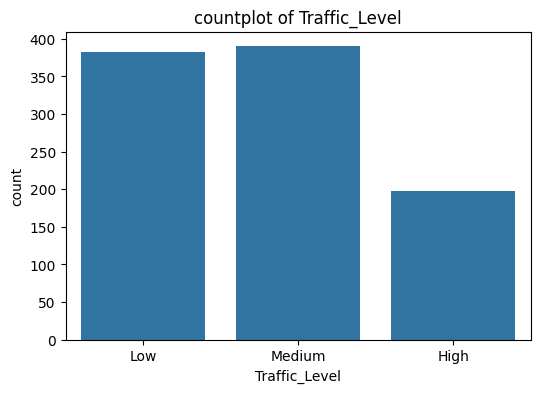

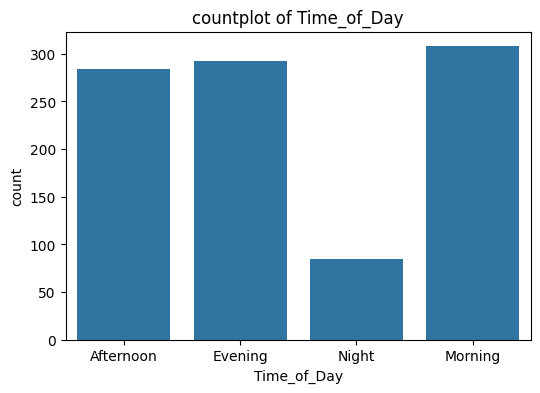

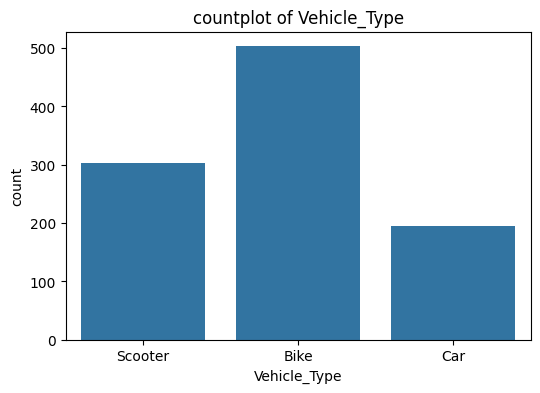

In [ ]:
##countplot de distribution des variables catégorielles 
for col in categ_col:
    plt.figure(figsize=(6,4))
    sns.countplot(data=data,x=col)
    plt.title(f'countplot of {col}')
    plt.show

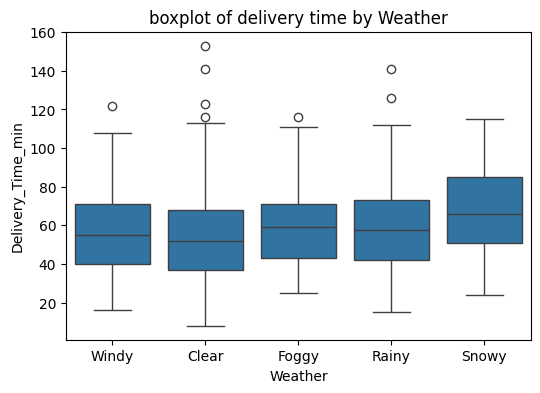

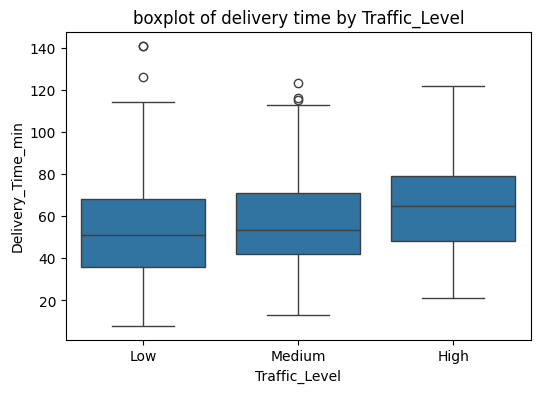

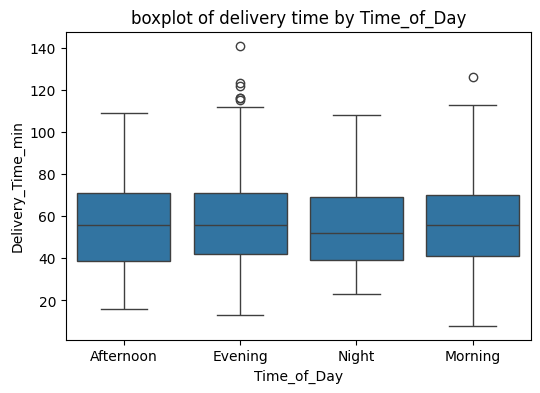

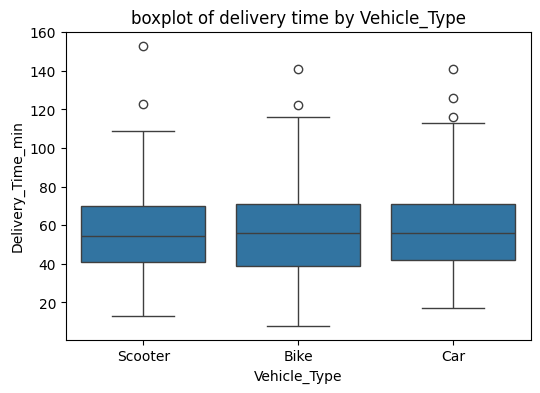

In [ ]:
##boxplot of delivery time bycategorical columns
for col in categ_col:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=col,y='Delivery_Time_min',data=data)
    plt.title(f'boxplot of delivery time by {col}')
    plt.show

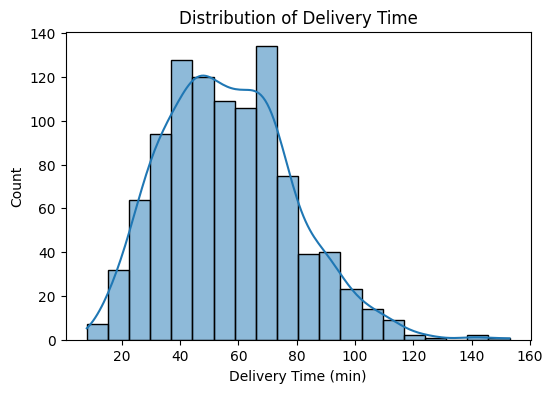

In [ ]:
##Analyse de la distribution de la variable cible.
plt.figure(figsize=(6,4))
sns.histplot(data['Delivery_Time_min'], bins=20, kde=True)
plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Count')
plt.show()